In [3]:
import pandas as pd

from google.colab import files
import pandas as pd

# Open file upload dialog
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(file_name)

df.head()

Saving Dataset_ATS_v2.csv to Dataset_ATS_v2.csv


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [4]:
print("\n" + "=" * 80)
print("LOADING AND EXPLORING THE DATA")
print("=" * 80)

df = pd.read_csv('Dataset_ATS_v2.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Basic Statistics ---")
print(df.describe())


LOADING AND EXPLORING THE DATA

Dataset Shape: (7043, 10)
Total Records: 7043
Total Features: 10

--- First 5 Rows ---
   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      41          Yes            No   
2  Female              0        Yes      52          Yes            No   
3  Female              0         No       1          Yes            No   
4    Male              0         No      67          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month              25   Yes  
1             DSL        One year              25    No  
2             DSL  Month-to-month              19    No  
3             DSL        One year              76   Yes  
4     Fiber optic  Month-to-month              51    No  

--- Data Types ---
gender             object
SeniorCitizen       int64
Dependents     

In [5]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
Contract,0
MonthlyCharges,0
Churn,0


In [6]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [7]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [8]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].head()

,Churn
0,1
1,0
2,0
3,1
4,0


In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
0,0,1,25,1,False,False,False,False,False,False,False
1,0,41,25,0,True,False,True,False,False,True,False
2,0,52,19,0,False,True,True,False,False,False,False
3,0,1,76,1,False,False,True,False,False,True,False
4,0,67,51,0,True,False,True,False,True,False,False


In [10]:

df_encoded.shape

(7043, 11)

In [11]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5634, 10), (1409, 10))

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7750177430801988

Confusion Matrix:
 [[927 115]
 [202 165]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85      1042
           1       0.59      0.45      0.51       367

    accuracy                           0.78      1409
   macro avg       0.71      0.67      0.68      1409
weighted avg       0.76      0.78      0.76      1409



In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report:\n", classification_report(y_test, y_pred_scaled))

Accuracy: 0.7771469127040455

Confusion Matrix:
 [[929 113]
 [201 166]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86      1042
           1       0.59      0.45      0.51       367

    accuracy                           0.78      1409
   macro avg       0.71      0.67      0.68      1409
weighted avg       0.76      0.78      0.77      1409



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Missing values:
gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

Categorical columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn']


In [17]:
import os

# Base project folder
BASE_DIR = "/content/Clustering_Project"

DATA_PREP_DIR = os.path.join(BASE_DIR, "Data_Preparation")
CLUSTER_DIR = os.path.join(BASE_DIR, "Clustering_Analysis")
FIG_DIR = os.path.join(CLUSTER_DIR, "figures")

for path in [DATA_PREP_DIR, CLUSTER_DIR, FIG_DIR]:
    os.makedirs(path, exist_ok=True)

print("Required folders created successfully.")

Required folders created successfully.


In [18]:
# Save encoded dataset
df_encoded.to_csv(os.path.join(DATA_PREP_DIR, "preprocessed_dataset.csv"), index=False)

# Save train/test if already created
X_train.to_csv(os.path.join(DATA_PREP_DIR, "train.csv"), index=False)
X_test.to_csv(os.path.join(DATA_PREP_DIR, "test.csv"), index=False)

print("Preprocessed data and splits saved.")

Preprocessed data and splits saved.


In [24]:
y_train.to_csv(os.path.join(DATA_PREP_DIR, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(DATA_PREP_DIR, "y_test.csv"), index=False)
print("y_train and y_test saved.")

# Save train/test split documentation
split_doc = f"""
Train/Test Split Documentation
================================
Total Records : 7043
Training Set  : {X_train.shape[0]} records ({X_train.shape[0]/7043*100:.1f}%)
Testing Set   : {X_test.shape[0]} records ({X_test.shape[0]/7043*100:.1f}%)
Features      : {X_train.shape[1]}
Split Ratio   : 80% Train / 20% Test
Random State  : 42
"""
with open(os.path.join(DATA_PREP_DIR, "train_test_split_documentation.txt"), "w") as f:
    f.write(split_doc)
print("Split documentation saved.")

y_train and y_test saved.
Split documentation saved.


In [25]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded.drop(columns=["Churn"], errors="ignore"))

# Save scaler
joblib.dump(scaler, os.path.join(DATA_PREP_DIR, "scaler.pkl"))

print("Scaling completed and scaler saved.")

Scaling completed and scaler saved.


In [26]:
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

print("Evaluating different K values...")
print(f"{'K':>3} {'Inertia':>12} {'Silhouette':>12} {'Davies-Bouldin':>15}")
print("-" * 50)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_train_scaled, cluster_labels)
    davies_bouldin = davies_bouldin_score(X_train_scaled, cluster_labels)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)

    print(f"{k:3d} {inertia:12.2f} {silhouette:12.4f} {davies_bouldin:15.4f}")

print("-" * 50)

Evaluating different K values...
  K      Inertia   Silhouette  Davies-Bouldin
--------------------------------------------------
  2     49637.74       0.1267          2.6348
  3     44284.41       0.1478          2.1824
  4     39911.92       0.1624          2.0091
  5     36083.29       0.1744          1.8524
  6     33191.82       0.1667          1.7298
  7     31736.78       0.1594          1.6205
  8     30513.50       0.1595          1.7045
  9     29503.11       0.1690          1.8071
 10     28584.46       0.1506          1.7248
--------------------------------------------------


In [27]:
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
optimal_k_davies = K_range[np.argmin(davies_bouldin_scores)]

print(f"Optimal K by Silhouette Score: {optimal_k_silhouette}")
print(f"Optimal K by Davies-Bouldin: {optimal_k_davies}")

optimal_k = optimal_k_silhouette

print(f"\n✓ SELECTED OPTIMAL K: {optimal_k}")
print(f"  Silhouette Score: {silhouette_scores[optimal_k-2]:.4f}")
print(f"  Davies-Bouldin Index: {davies_bouldin_scores[optimal_k-2]:.4f}")

Optimal K by Silhouette Score: 5
Optimal K by Davies-Bouldin: 7

✓ SELECTED OPTIMAL K: 5
  Silhouette Score: 0.1744
  Davies-Bouldin Index: 1.8524


Silhouette score is used as the primary selection criterion
because it measures both cluster cohesion and separation.

Although Davies-Bouldin suggests k=7, silhouette indicates
stronger overall clustering structure at k=5.

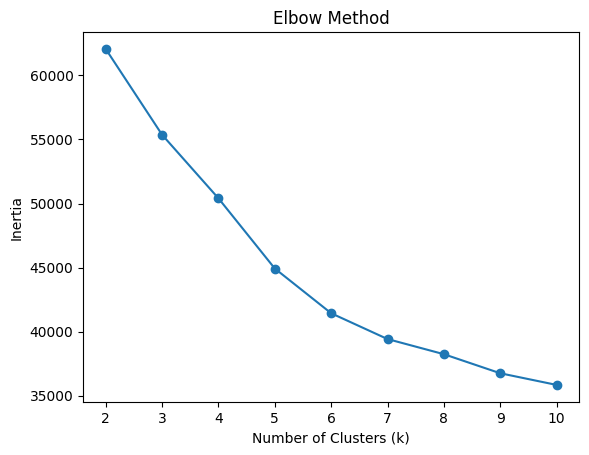

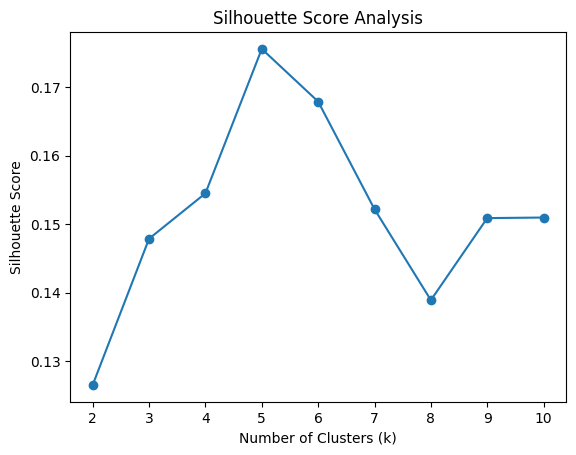

Best k based on silhouette: 5


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np
import os

k_range = range(2, 11)
inertia = []
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_) # Append to the list
    sil_scores.append(silhouette_score(X_scaled, cluster_labels)) # Append to the list
    # davies_bouldin is calculated in the previous cell but not used in the plot here, so no need to append to a list if not plotting it.

# Elbow Plot
plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig(os.path.join(FIG_DIR, "elbow_curve.png"), dpi=200)
plt.show()

# Silhouette Plot
plt.figure()
plt.plot(k_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")
plt.savefig(os.path.join(FIG_DIR, "silhouette_scores.png"), dpi=200)
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print("Best k based on silhouette:", best_k)

In [29]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
final_kmeans.fit(X_scaled)

# Save model
joblib.dump(final_kmeans, os.path.join(CLUSTER_DIR, "kmeans_model.pkl"))

print("Final KMeans model saved.")

Final KMeans model saved.


In [30]:
from sklearn.cluster import KMeans
import joblib
import os

# Ensure the model is created and saved if it doesn't exist or wasn't saved previously
try:
    final_kmeans = joblib.load(os.path.join(CLUSTER_DIR, "kmeans_model.pkl"))
except FileNotFoundError:
    print("KMeans model not found, recreating and saving it...")
    # Re-create and fit the model
    final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
    final_kmeans.fit(X_scaled)
    # Save model
    joblib.dump(final_kmeans, os.path.join(CLUSTER_DIR, "kmeans_model.pkl"))
    print("KMeans model recreated and saved.")

cluster_labels = final_kmeans.predict(X_scaled)

clustered_data = df_encoded.copy()
clustered_data["Cluster"] = cluster_labels

clustered_data.to_csv(
    os.path.join(CLUSTER_DIR, "clustered_dataset_with_labels.csv"),
    index=False
)

print("Clustered dataset saved.")

Clustered dataset saved.


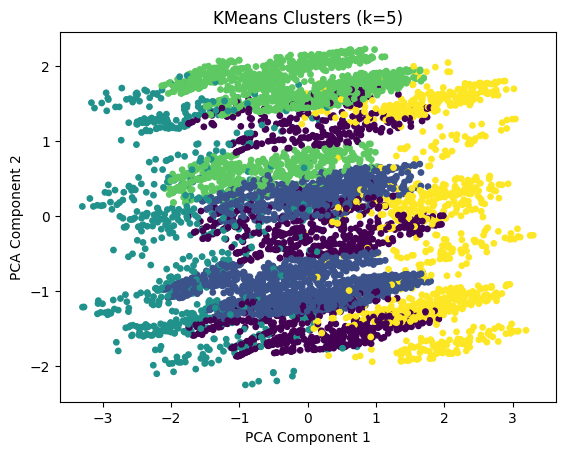

PCA cluster visualization saved.


In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=15)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"KMeans Clusters (k={best_k})")
plt.savefig(os.path.join(FIG_DIR, "pca_cluster_visualization.png"), dpi=200)
plt.show()

print("PCA cluster visualization saved.")

CLUSTER PROFILES (Mean values per cluster)
         SeniorCitizen  tenure  MonthlyCharges  Churn  gender_Male  \
Cluster                                                              
0                 0.00   32.22           64.95   0.23         0.52   
1                 0.00   31.00           64.50   0.26         0.49   
2                 0.15   31.74           42.02   0.25         0.51   
3                 0.00   34.07           62.43   0.21         0.51   
4                 1.00   33.50           83.70   0.42         0.50   

         Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
Cluster                                                        
0                  0.34               1.0               0.52   
1                  0.22               1.0               0.11   
2                  0.30               0.0               0.38   
3                  0.53               1.0               0.82   
4                  0.08               1.0               0.43   

         Internet

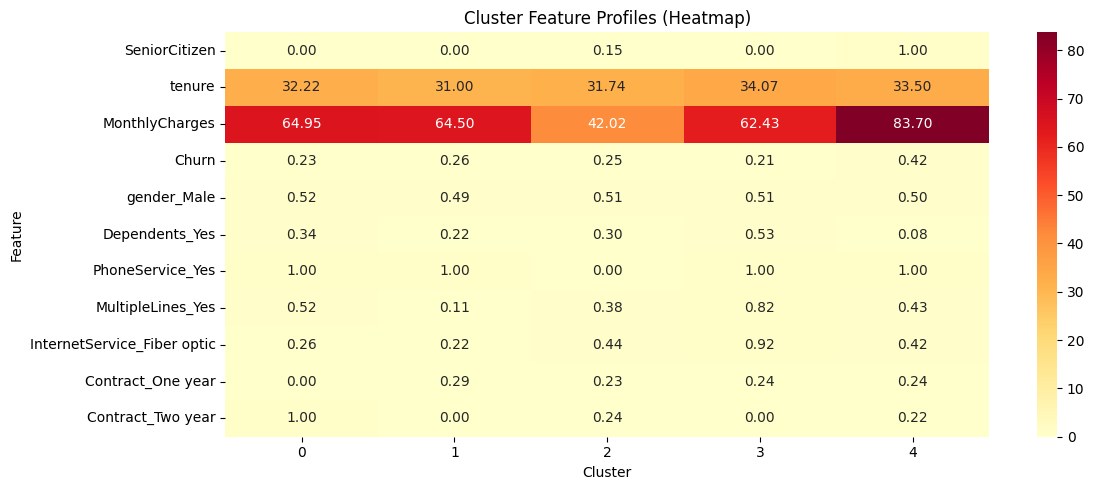

Cluster heatmap saved.


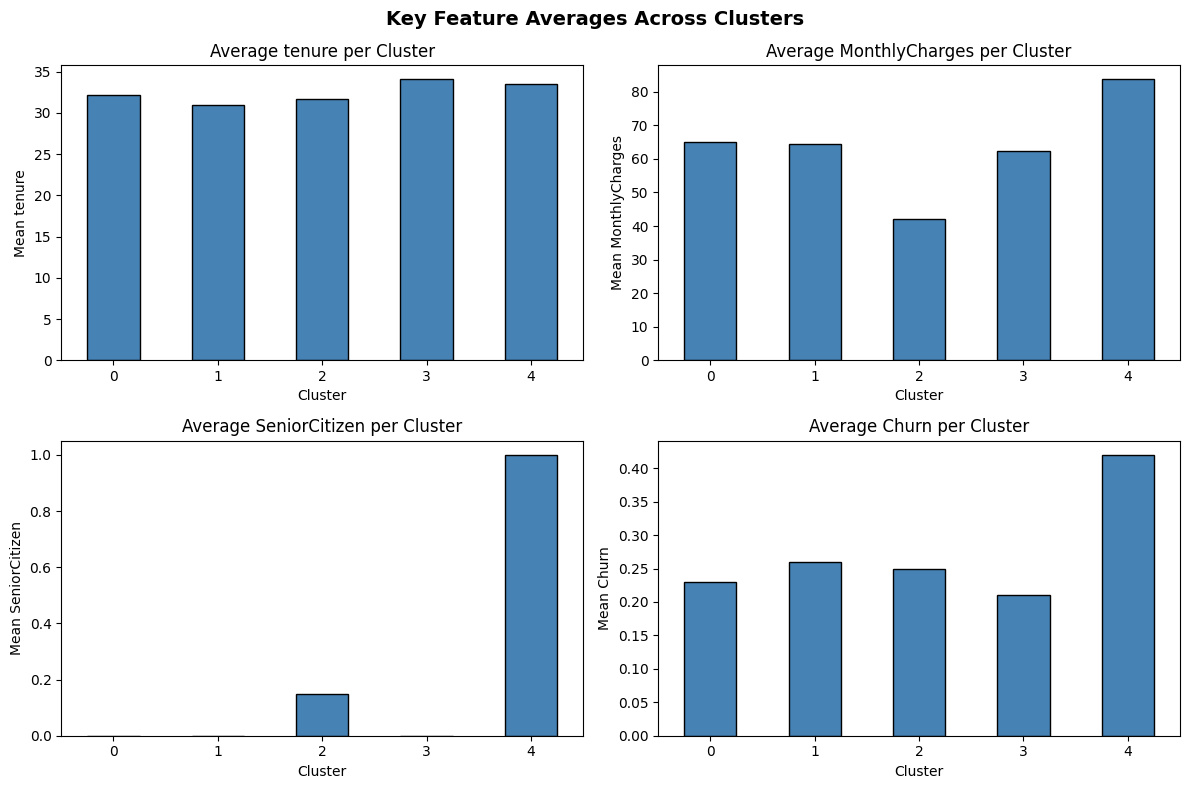

Cluster bar charts saved.

--- Churn Rate per Cluster ---
  Cluster 0: 23.2% churn rate
  Cluster 1: 25.7% churn rate
  Cluster 2: 24.9% churn rate
  Cluster 3: 21.5% churn rate
  Cluster 4: 41.6% churn rate


In [32]:
# ============================================================
# CLUSTER PROFILING & LABELING
# ============================================================

# Add cluster labels to the encoded dataframe
clustered_data = df_encoded.copy()
clustered_data["Cluster"] = cluster_labels

# Step 1: Generate cluster profiles (mean values per cluster)
cluster_profile = clustered_data.groupby("Cluster").mean().round(2)
print("=" * 80)
print("CLUSTER PROFILES (Mean values per cluster)")
print("=" * 80)
print(cluster_profile)

# Step 2: Cluster sizes
print("\n--- Cluster Sizes ---")
print(clustered_data["Cluster"].value_counts().sort_index())

# Step 3: Visualise cluster profiles as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile.T, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Cluster Feature Profiles (Heatmap)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cluster_heatmap.png"), dpi=200)
plt.show()
print("Cluster heatmap saved.")

# Step 4: Bar chart for key features per cluster
key_features = ["tenure", "MonthlyCharges", "SeniorCitizen", "Churn"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    cluster_profile[feature].plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].set_title(f"Average {feature} per Cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(f"Mean {feature}")
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle("Key Feature Averages Across Clusters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cluster_feature_bars.png"), dpi=200)
plt.show()
print("Cluster bar charts saved.")

# Step 5: Print churn rate per cluster clearly
print("\n--- Churn Rate per Cluster ---")
churn_rate = clustered_data.groupby("Cluster")["Churn"].mean().round(4) * 100
for cluster, rate in churn_rate.items():
    print(f"  Cluster {cluster}: {rate:.1f}% churn rate")

In [33]:
cluster_profile = clustered_data.groupby("Cluster").mean(numeric_only=True)
cluster_profile.to_csv(
    os.path.join(CLUSTER_DIR, "cluster_profiles.csv")
)

print("Cluster profile saved.")

Cluster profile saved.


In [34]:
import shutil
shutil.make_archive("/content/Final_Submission", "zip", BASE_DIR)

'/content/Final_Submission.zip'